In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/nassau_candy_cleaned.csv"
)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (10194, 32)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Calculated Gross Profit', 'Profit Difference', 'Order Date Raw', 'Ship Date Raw', 'Order Date Parsed', 'Ship Date Parsed', 'Lead Time Days', 'Profit Margin', 'Sales per Unit', 'Profit per Unit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [ ]:
factory_coordinates = pd.DataFrame({
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],
    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
})

display(factory_coordinates)

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [ ]:
product_factory = pd.DataFrame({
    "Product Name": [
        "Wonka Bar - Nutty Crunch Surprise",
        "Wonka Bar - Fudge Mallows",
        "Wonka Bar -Scrumdiddlyumptious",
        "Wonka Bar - Milk Chocolate",
        "Wonka Bar - Triple Dazzle Caramel",
        "Laffy Taffy",
        "SweeTARTS",
        "Nerds",
        "Fun Dip",
        "Fizzy Lifting Drinks",
        "Everlasting Gobstopper",
        "Hair Toffee",
        "Lickable Wallpaper",
        "Wonka Gum",
        "Kazookles"
    ],
    "Factory": [
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Wicked Choccy's",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory",
        "Secret Factory",
        "Secret Factory",
        "The Other Factory"
    ]
})

display(product_factory)

,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
df["Product Name"] = (
    df["Product Name"]
    .astype(str)
    .str.strip()
)

product_factory["Product Name"] = (
    product_factory["Product Name"]
    .astype(str)
    .str.strip()
)

In [ ]:
dataset_products = set(df["Product Name"].unique())
mapping_products = set(product_factory["Product Name"].unique())

unmatched_products = sorted(
    dataset_products - mapping_products
)

print("Number of unique products in dataset:", len(dataset_products))
print("Products in mapping:", len(mapping_products))
print("Unmatched products:", len(unmatched_products))

if unmatched_products:
    print("\nUnmatched product names:")
    for product in unmatched_products:
        print(repr(product))
else:
    print("\nAll dataset products have a factory mapping.")

Number of unique products in dataset: 15
Products in mapping: 15
Unmatched products: 0

All dataset products have a factory mapping.


In [ ]:
duplicate_mapping = (
    product_factory
    .groupby("Product Name")["Factory"]
    .nunique()
)

print(
    "Products mapped to more than one factory:",
    (duplicate_mapping > 1).sum()
)

Products mapped to more than one factory: 0


In [ ]:
df = df.merge(
    product_factory,
    on="Product Name",
    how="left",
    validate="many_to_one"
)

In [ ]:
print("Dataset shape after factory mapping:", df.shape)

print(
    "Missing Factory Assignments:",
    df["Factory"].isna().sum()
)

Dataset shape after factory mapping: (10194, 33)
Missing Factory Assignments: 0


In [ ]:
factory_check = (
    df[["Product Name", "Factory"]]
    .drop_duplicates()
    .sort_values("Product Name")
)

display(factory_check)

,Product Name,Factory
4729,Everlasting Gobstopper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
5007,Fun Dip,Sugar Shack
4435,Hair Toffee,The Other Factory
26,Kazookles,The Other Factory
226,Laffy Taffy,Sugar Shack
136,Lickable Wallpaper,Secret Factory
1490,Nerds,Sugar Shack
973,SweeTARTS,Sugar Shack
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts


In [ ]:
factory_distribution = (
    df["Factory"]
    .value_counts()
)

display(factory_distribution)

,count
Factory,
Lot's O' Nuts,5692
Wicked Choccy's,4152
Secret Factory,217
The Other Factory,100
Sugar Shack,33


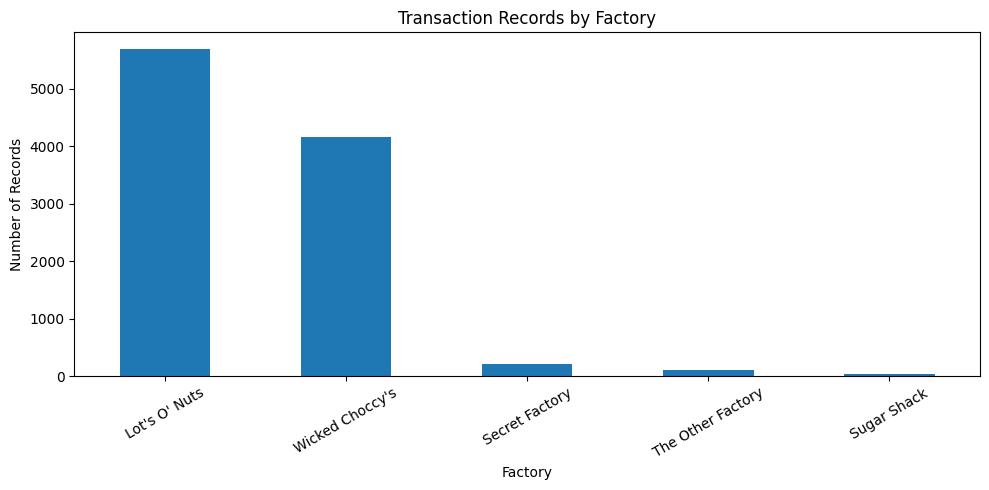

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

factory_distribution.plot(kind="bar")

plt.title("Transaction Records by Factory")
plt.xlabel("Factory")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "../05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
df = df.merge(
    factory_coordinates,
    on="Factory",
    how="left",
    validate="many_to_one"
)

In [ ]:
print(
    "Missing Factory Latitude:",
    df["Latitude"].isna().sum()
)

print(
    "Missing Factory Longitude:",
    df["Longitude"].isna().sum()
)

Missing Factory Latitude: 0
Missing Factory Longitude: 0


In [ ]:
print("Current shape:", df.shape)

display(
    df[
        [
            "Product Name",
            "Factory",
            "Latitude",
            "Longitude"
        ]
    ].head(10)
)

Current shape: (10194, 39)


,Product Name,Factory,Latitude,Longitude
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371


In [ ]:
df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    (df["Gross Profit"] / df["Sales"]) * 100,
    0
)

In [ ]:
df["Sales per Unit"] = np.where(
    df["Units"] != 0,
    df["Sales"] / df["Units"],
    0
)

In [ ]:
df["Profit per Unit"] = np.where(
    df["Units"] != 0,
    df["Gross Profit"] / df["Units"],
    0
)

In [ ]:
display(
    df[
        [
            "Sales",
            "Units",
            "Gross Profit",
            "Profit Margin",
            "Sales per Unit",
            "Profit per Unit"
        ]
    ].head(10)
)

,Sales,Units,Gross Profit,Profit Margin,Sales per Unit,Profit per Unit
0,6.50,2,4.22,64.923077,3.25,2.11
1,7.50,2,4.90,65.333333,3.75,2.45
2,10.47,3,7.47,71.346705,3.49,2.49
3,10.80,3,7.50,69.444444,3.60,2.50
4,11.25,3,7.35,65.333333,3.75,2.45
5,32.40,9,22.50,69.444444,3.60,2.50
6,7.50,2,4.90,65.333333,3.75,2.45
7,9.75,3,6.33,64.923077,3.25,2.11
8,6.98,2,4.98,71.346705,3.49,2.49
9,13.00,4,8.44,64.923077,3.25,2.11


In [ ]:
numeric_features = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Lead Time Days",
    "Profit Margin",
    "Sales per Unit",
    "Profit per Unit"
]

display(
    df[numeric_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,13.908537,11.341020,1.250000,7.200000,10.800000,18.000000,260.0
Units,10194.0,3.791838,2.228317,1.000000,2.000000,3.000000,5.000000,14.0
Gross Profit,10194.0,9.166451,6.643740,0.250000,4.900000,7.470000,12.250000,130.0
Cost,10194.0,4.742087,5.061647,0.600000,2.400000,3.600000,5.700000,130.0
Lead Time Days,10194.0,1320.841868,262.444892,904.000000,1271.000000,1274.000000,1638.000000,1642.0
Profit Margin,10194.0,66.514045,6.721012,7.692308,65.333333,66.666667,69.444444,80.0
Sales per Unit,10194.0,3.654257,1.611875,1.250000,3.490000,3.600000,3.600000,20.0
Profit per Unit,10194.0,2.412539,0.806007,0.250000,2.400000,2.450000,2.490000,10.0


In [ ]:
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier %": count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Sales,-9.000000,34.200000,245,2.403375
1,Units,-2.500000,9.500000,175,1.716696
2,Gross Profit,-6.125000,23.275000,217,2.128703
3,Cost,-2.550000,10.650000,397,3.894448
4,Lead Time Days,720.500000,2188.500000,0,0.000000
5,Profit Margin,59.166667,75.611111,334,3.276437
6,Sales per Unit,3.325000,3.765000,2481,24.337846
7,Profit per Unit,2.265000,2.625000,2487,24.396704


In [ ]:
categorical_columns = [
    "Ship Mode",
    "Country/Region",
    "Division",
    "Region",
    "Factory"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Ship Mode
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

 Country/Region
Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

 Division
Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

 Region
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

 Factory
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


In [ ]:
model_df = df.copy()

columns_to_drop = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Product ID",
    "Order Date Raw",
    "Ship Date Raw"
]

model_df = model_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

In [ ]:
print("Model dataset shape:", model_df.shape)

display(model_df.head())

Model dataset shape: (10194, 33)


,Order Date,Ship Date,Ship Mode,Country/Region,City,State/Province,Postal Code,Division,Region,Product Name,...,Order Month,Order Quarter,Order DayOfWeek,Factory,Latitude_x,Longitude_x,Latitude_y,Longitude_y,Latitude,Longitude
0,3/1/2024,30-06-2026,Standard Class,United States,Houston,Texas,77095,Chocolate,Interior,Wonka Bar - Milk Chocolate,...,1,1,2,Wicked Choccy's,32.076176,-81.088371,32.076176,-81.088371,32.076176,-81.088371
1,4/1/2024,1/7/2026,Standard Class,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar - Triple Dazzle Caramel,...,1,1,3,Wicked Choccy's,32.076176,-81.088371,32.076176,-81.088371,32.076176,-81.088371
2,4/1/2024,1/7/2026,Standard Class,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar - Nutty Crunch Surprise,...,1,1,3,Lot's O' Nuts,32.881893,-111.768036,32.881893,-111.768036,32.881893,-111.768036
3,4/1/2024,1/7/2026,Standard Class,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar -Scrumdiddlyumptious,...,1,1,3,Lot's O' Nuts,32.881893,-111.768036,32.881893,-111.768036,32.881893,-111.768036
4,5/1/2024,5/7/2026,Standard Class,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,Wonka Bar - Triple Dazzle Caramel,...,1,1,4,Wicked Choccy's,32.076176,-81.088371,32.076176,-81.088371,32.076176,-81.088371


In [ ]:
missing_model = pd.DataFrame({
    "Missing Count": model_df.isnull().sum(),
    "Missing %": model_df.isnull().mean() * 100
})

display(
    missing_model[
        missing_model["Missing Count"] > 0
    ]
)

,Missing Count,Missing %


In [ ]:
model_df.to_csv(
    "/content/nassau_candy_cleaned.csv",
    index=False
)

print("Model-ready dataset saved successfully.")

Model-ready dataset saved successfully.


In [ ]:
import os

os.makedirs("../03_Factory_Data", exist_ok=True)

factory_coordinates.to_csv(
    "../03_Factory_Data/factory_coordinates.csv",
    index=False
)

product_factory.to_csv(
    "../03_Factory_Data/product_factory_mapping.csv",
    index=False
)

print("Factory datasets saved successfully.")

Factory datasets saved successfully.


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
print(os.listdir())

['.config', '.ipynb_checkpoints', 'nassau_candy_cleaned.csv', 'sample_data']


In [ ]:
import os

print(os.listdir("../03_Factory_Data"))

['product_factory_mapping.csv', 'factory_coordinates.csv']


In [ ]:
factory_coordinates

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [ ]:
product_factory

,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
print("Factory Coordinates:")
display(factory_coordinates.head())

print("Product Factory Mapping:")
display(product_factory.head())

Factory Coordinates:


,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


Product Factory Mapping:


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [ ]:
import pandas as pd

factory_coordinates_check = pd.read_csv(
    "../03_Factory_Data/factory_coordinates.csv"
)

product_factory_check = pd.read_csv(
    "../03_Factory_Data/product_factory_mapping.csv"
)

display(factory_coordinates_check.head())
display(product_factory_check.head())

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [ ]:
import pandas as pd

factory_coordinates = pd.read_csv(
    "../03_Factory_Data/factory_coordinates.csv"
)

product_factory = pd.read_csv(
    "../03_Factory_Data/product_factory_mapping.csv"
)

display(factory_coordinates)
display(product_factory)

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(factory_coordinates)
display(product_factory)

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
display(factory_coordinates.head(10))
display(product_factory.head(10))

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
import os

print("CURRENT DIRECTORY:")
print(os.getcwd())

print("\nFILES/FOLDERS ONE LEVEL ABOVE:")
print(os.listdir(".."))

print("\nSEARCHING FOR YOUR CSV FILES...")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in ["factory_coordinates.csv", "product_factory_mapping.csv"]:
            print(os.path.join(root, file))

CURRENT DIRECTORY:
/content

FILES/FOLDERS ONE LEVEL ABOVE:
['sbin', 'lib', 'sys', 'root', 'home', 'var', 'boot', 'bin', 'opt', 'dev', 'proc', 'srv', 'media', 'tmp', 'lib64', 'run', 'etc', 'libx32', 'usr', 'lib32', 'mnt', 'kaggle', 'content', '03_Factory_Data', '05_Results', '.dockerenv', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz']

SEARCHING FOR YOUR CSV FILES...


In [ ]:
import os

print("CURRENT DIRECTORY:")
print(os.getcwd())

print("\nALL CSV FILES FOUND:")
for root, dirs, files in os.walk("/"):
    for file in files:
        if file in ["factory_coordinates.csv", "product_factory_mapping.csv"]:
            print(os.path.join(root, file))

CURRENT DIRECTORY:
/content

ALL CSV FILES FOUND:
/03_Factory_Data/product_factory_mapping.csv
/03_Factory_Data/factory_coordinates.csv


In [ ]:
import os

os.makedirs("/content/03_Factory_Data", exist_ok=True)

factory_coordinates.to_csv(
    "/content/03_Factory_Data/factory_coordinates.csv",
    index=False
)

product_factory.to_csv(
    "/content/03_Factory_Data/product_factory_mapping.csv",
    index=False
)

print("Files saved!")
print(os.listdir("/content/03_Factory_Data"))

Files saved!
['product_factory_mapping.csv', 'factory_coordinates.csv']


In [ ]:
import pandas as pd

fc = pd.read_csv("/content/03_Factory_Data/factory_coordinates.csv")
pf = pd.read_csv("/content/03_Factory_Data/product_factory_mapping.csv")

print("FACTORY COORDINATES")
display(fc.head())

print("PRODUCT FACTORY MAPPING")
display(pf.head())

FACTORY COORDINATES


,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


PRODUCT FACTORY MAPPING


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [ ]:
import os

print(os.listdir("/content/03_Factory_Data"))

['product_factory_mapping.csv', 'factory_coordinates.csv']


In [ ]:
factory_coordinates.to_csv(
    "/content/03_Factory_Data/factory_coordinates.csv",
    index=False
)

product_factory.to_csv(
    "/content/03_Factory_Data/product_factory_mapping.csv",
    index=False
)

print("Factory datasets saved successfully!")

print(os.listdir("/content/03_Factory_Data"))

Factory datasets saved successfully!
['product_factory_mapping.csv', 'factory_coordinates.csv']


In [ ]:
print("Factory Coordinates:")
display(factory_coordinates.head(10))

print("Product Factory Mapping:")
display(product_factory.head(10))

Factory Coordinates:


,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


Product Factory Mapping:


,Product Name,Factory
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
1,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
3,Wonka Bar - Milk Chocolate,Wicked Choccy's
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Laffy Taffy,Sugar Shack
6,SweeTARTS,Sugar Shack
7,Nerds,Sugar Shack
8,Fun Dip,Sugar Shack
9,Fizzy Lifting Drinks,Sugar Shack


In [ ]:
import os

# Check that the DataFrames exist
print("factory_coordinates rows:", len(factory_coordinates))
print("product_factory rows:", len(product_factory))

# Save directly to /content
file1 = "/content/factory_coordinates.csv"
file2 = "/content/product_factory_mapping.csv"

factory_coordinates.to_csv(file1, index=False)
product_factory.to_csv(file2, index=False)

# Verify files physically exist
print("\nFile 1 exists:", os.path.exists(file1))
print("File 2 exists:", os.path.exists(file2))

# Show file sizes
if os.path.exists(file1):
    print("factory_coordinates.csv size:", os.path.getsize(file1), "bytes")

if os.path.exists(file2):
    print("product_factory_mapping.csv size:", os.path.getsize(file2), "bytes")

# Show files in /content
print("\nCSV files in /content:")
print([f for f in os.listdir("/content") if f.endswith(".csv")])

factory_coordinates rows: 5
product_factory rows: 15

File 1 exists: True
File 2 exists: True
factory_coordinates.csv size: 204 bytes
product_factory_mapping.csv size: 519 bytes

CSV files in /content:
['product_factory_mapping.csv', 'factory_coordinates.csv', 'nassau_candy_cleaned.csv']


In [ ]:
import os

os.makedirs("/content/03_Factory_Data", exist_ok=True)
os.makedirs("/content/05_Results", exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
import os

# Create folder if it doesn't already exist
os.makedirs("/content/03_Factory_Data", exist_ok=True)

# Save factory datasets
factory_coordinates.to_csv(
    "/content/03_Factory_Data/factory_coordinates.csv",
    index=False
)

product_factory.to_csv(
    "/content/03_Factory_Data/product_factory_mapping.csv",
    index=False
)

print("Factory datasets saved successfully!")

# Verify
print(os.listdir("/content/03_Factory_Data"))

Factory datasets saved successfully!
['product_factory_mapping.csv', 'factory_coordinates.csv']


In [ ]:
import os

os.makedirs("/content/05_Results", exist_ok=True)

plt.savefig(
    "/content/05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")

<Figure size 640x480 with 0 Axes>

Graph saved successfully!


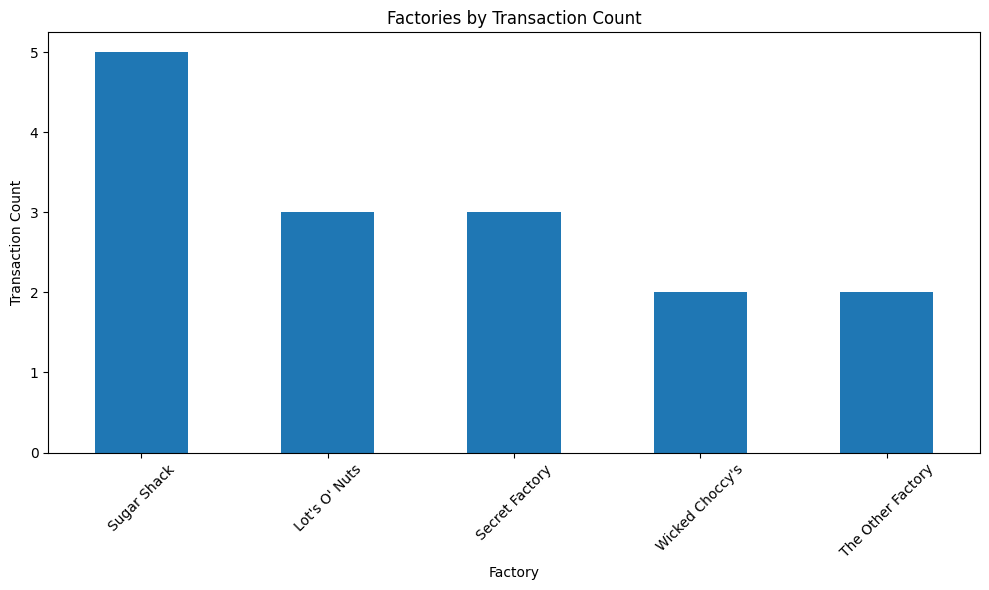

In [ ]:
import matplotlib.pyplot as plt

# Create the graph
plt.figure(figsize=(10, 6))

factory_counts = product_factory["Factory"].value_counts()

factory_counts.plot(
    kind="bar"
)

plt.title("Factories by Transaction Count")
plt.xlabel("Factory")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()

# Save the graph
plt.savefig(
    "/content/05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(product_factory.columns)

Index(['Product Name', 'Factory'], dtype='object')


In [ ]:
product_factory["Factory"]

,Factory
0,Lot's O' Nuts
1,Lot's O' Nuts
2,Lot's O' Nuts
3,Wicked Choccy's
4,Wicked Choccy's
5,Sugar Shack
6,Sugar Shack
7,Sugar Shack
8,Sugar Shack
9,Sugar Shack


In [ ]:
print(product_factory.head())
print(product_factory.shape)

                        Product Name          Factory
0  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts
1          Wonka Bar - Fudge Mallows    Lot's O' Nuts
2     Wonka Bar -Scrumdiddlyumptious    Lot's O' Nuts
3         Wonka Bar - Milk Chocolate  Wicked Choccy's
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's
(15, 2)


In [ ]:
print(product_factory["Factory"].value_counts())

Factory
Sugar Shack          5
Lot's O' Nuts        3
Secret Factory       3
Wicked Choccy's      2
The Other Factory    2
Name: count, dtype: int64


In [ ]:
print(product_factory.columns)
print(product_factory.head())

Index(['Product Name', 'Factory'], dtype='object')
                        Product Name          Factory
0  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts
1          Wonka Bar - Fudge Mallows    Lot's O' Nuts
2     Wonka Bar -Scrumdiddlyumptious    Lot's O' Nuts
3         Wonka Bar - Milk Chocolate  Wicked Choccy's
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's


In [ ]:
import os

# Make sure the folder exists
os.makedirs("/content/05_Results", exist_ok=True)

# Save the current graph
plt.savefig(
    "/content/05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

print("Image saved successfully!")

Image saved successfully!


<Figure size 640x480 with 0 Axes>

In [ ]:
print(os.listdir("/content/05_Results"))

['.ipynb_checkpoints', 'Factories_by_Transaction_Count.png']


In [ ]:
plt.savefig(
    "/content/05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

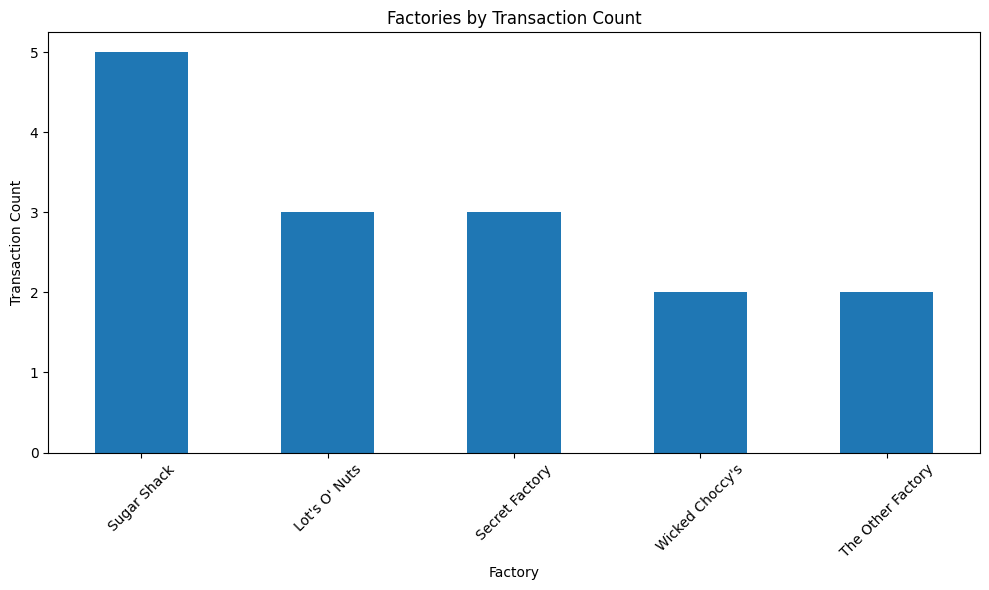

Graph saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# CREATE THE GRAPH AGAIN
factory_counts = product_factory["Factory"].value_counts()

plt.figure(figsize=(10, 6))

factory_counts.plot(kind="bar")

plt.title("Factories by Transaction Count")
plt.xlabel("Factory")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)

plt.tight_layout()

# SAVE BEFORE plt.show()
plt.savefig(
    "/content/05_Results/Factories_by_Transaction_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")